## Как получить данные с Open Street Map с помощью Python

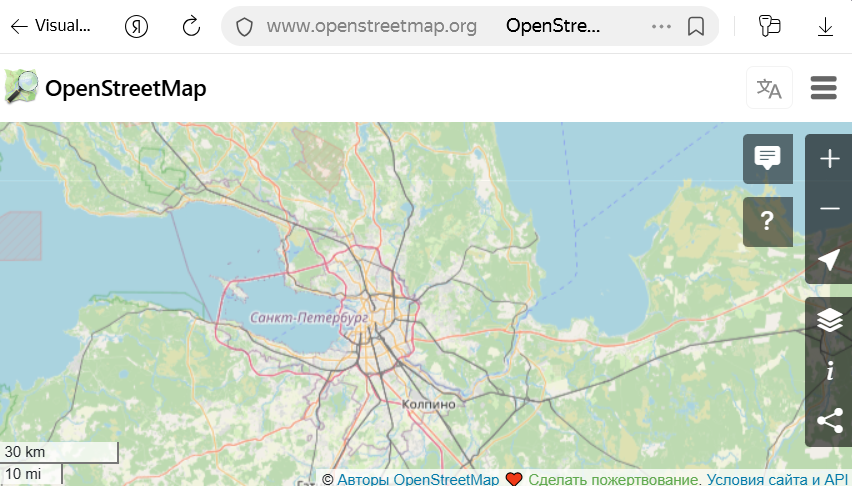

OSM ([OpenStreetMap](https://www.openstreetmap.org)) — бесплатная редактируемая карта мира, которую создают пользователи (по принципу Википедии, но для картографии).

Каждый может добавлять, редактировать и использовать данные — улицы, здания, тропы, водоёмы и т. д.

Данные распространяются под свободной лицензией — их можно применять в навигационных приложениях, веб‑сервисах и офлайн‑картах.

#### Что такое OSM API? 
OSM API (OpenStreetMap API) — это интерфейс для чтения и записи картографических данных в проекте OpenStreetMap. Он позволяет:

* получать данные карты в формате XML;

* загружать правки от пользователей;

* синхронизировать данные между центральным сервером и клиентскими приложениями.

[Overpass Turbo](https://overpass-turbo.eu/) - графический интерфейс к серверу Overpass API, предназначенному для запросов к OSM.  

###  Работа с модулем OSMnx

**OSMnx** — библиотека Python для загрузки, анализа и визуализации данных OpenStreetMap (OSM).

Ключевые возможности:

* загрузка дорожной сети по названию места или границам;

* построение маршрутов и расчёт расстояний;

* анализ графов (степень вершин, связность, центральность);

* визуализация сетей и маршрутов;

* экспорт данных в форматы GIS (Shapefile, GeoPackage).

In [ ]:
# Установка
pip install osmnx
pip install geopandas

In [1]:
# модули, которые понадобятся для работы
import osmnx as ox
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

#### Загрузка данных
1. Загрузка дорожной сети по названию

Узлов: 17, Рёбер: 40


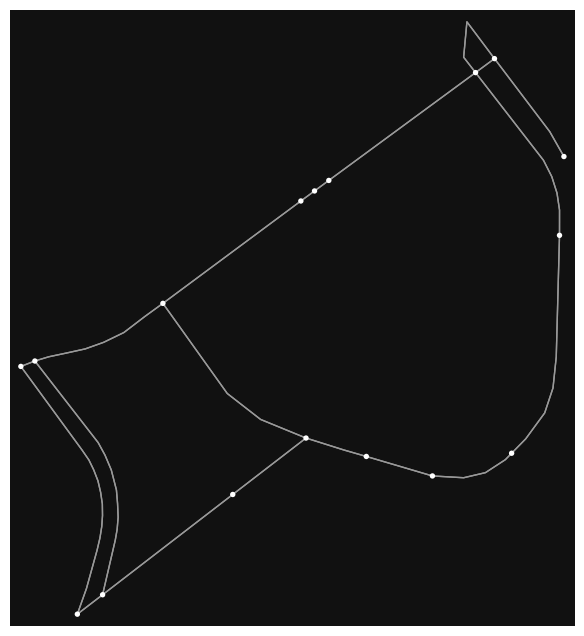

In [3]:
# Загружаем пешеходную сеть вокруг Дворцовой площади
G = ox.graph_from_place('Дворцовая площадь, Санкт‑Петербург, Россия', network_type='walk')
print(f"Узлов: {G.number_of_nodes()}, Рёбер: {G.number_of_edges()}")
ox.plot_graph(G)
plt.show()

Параметры *network_type*:

    *'walk'* — пешеходные дорожки и тротуары;

    *'drive'* — автомобильные дороги;

    *'bike'* — велодорожки;

    *'all'* — все типы путей

2. Загрузка по координатам и радиусу

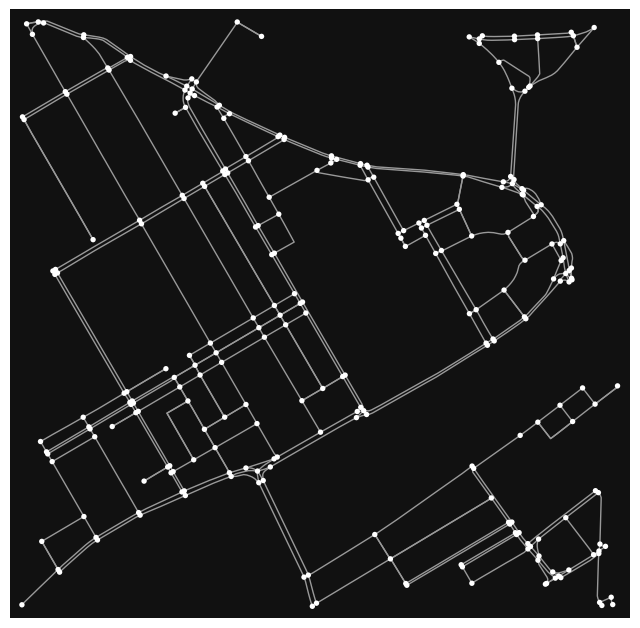

In [4]:
# Координаты стрелки Васильевского острова
center_point = (59.9414, 30.2917)
G = ox.graph_from_point(center_point, dist=1000, network_type='drive')
ox.plot_graph(G)
plt.show()

3. Загрузка по полигону

In [18]:
admiral_district = ox.geocode_to_gdf('Адмиралтейский район, Санкт‑Петербург')
admiral_district

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((30.25023 59.90129, 30.25112 59.90103...",30.250229,59.896031,30.342678,59.941057,156841575,relation,1114193,59.918443,30.302795,boundary,administrative,10,0.460048,administrative,Admiralteysky District,"Admiralteysky District, Сенной округ, Saint Pe..."


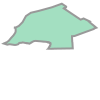

In [20]:
admiral_district.iloc[0].geometry

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

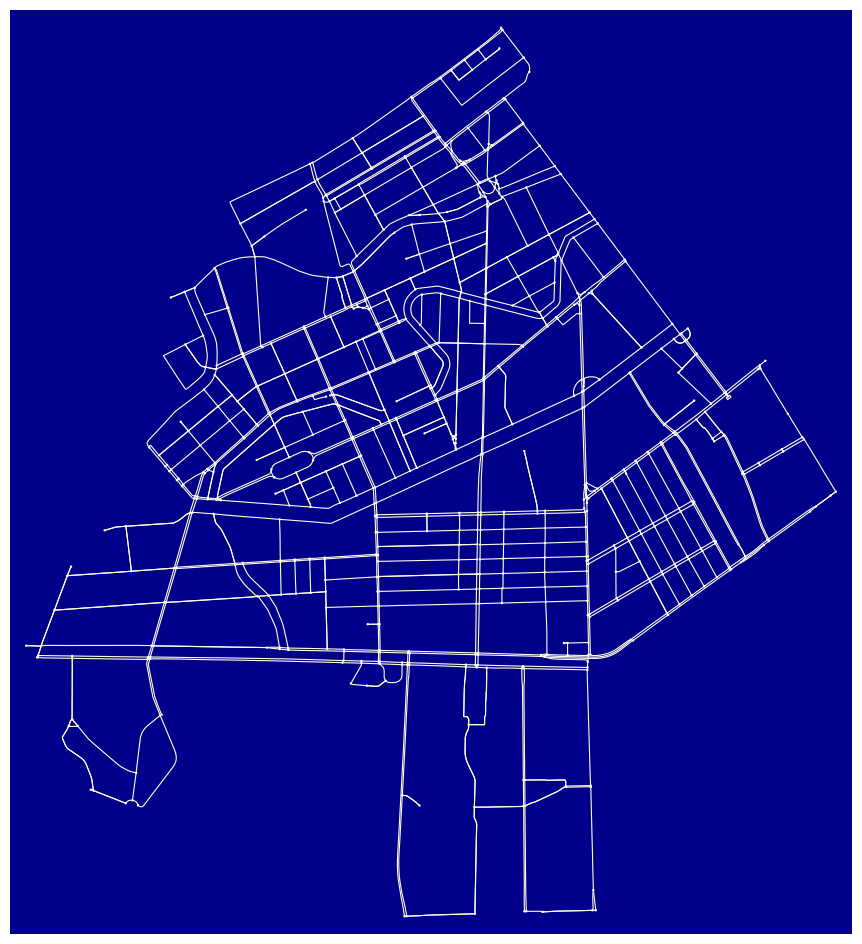

In [34]:
# Границы Адмиралтейского района
G = ox.graph_from_polygon(
    admiral_district.iloc[0].geometry,
    network_type='drive'
)
ox.plot_graph(
     G,
    figsize=(12, 12),
    bgcolor='darkblue',
    edge_color='lightyellow',
    node_size=3,
    edge_linewidth=0.8,
    show=False
)

### Загрузка данных о зданиях
 1. Загрузка зданий вокруг Дворцовой площади

In [39]:
# Загружаем здания вокруг Дворцовой площади
gdf_buildings = ox.features_from_address(
    'Дворцовая площадь, Санкт‑Петербург, Россия',
    tags={'building': True},
    dist=500  # радиус в метрах
)
print(f"Загружено зданий: {len(gdf_buildings)}")
gdf_buildings.head(5)

Загружено зданий: 257


geometry  \
element  id                                                          
relation 69424   POLYGON ((30.31208 59.9408, 30.31215 59.94075,...   
         112183  POLYGON ((30.30498 59.93786, 30.30526 59.93797...   
         270634  POLYGON ((30.31529 59.9419, 30.31525 59.94194,...   
         419767  POLYGON ((30.31688 59.93586, 30.31683 59.9358,...   
         419768  POLYGON ((30.31732 59.93633, 30.31733 59.93632...   

                addr:housenumber addr:postcode                addr:street  \
element  id                                                                 
relation 69424           38 литА        190000       Дворцовая набережная   
         112183            12-14        190098  Адмиралтейская набережная   
         270634               34        190000       Дворцовая набережная   
         419767               11        191186      Большая Морская улица   
         419768             13/9        191186           Невский проспект   

                   building building:levels        alt_name  \
element  id                                                   
relation 69424          yes               3             NaN   
         112183  apartments               4             NaN   
         270634         yes               3  Старый Эрмитаж   
         419767  apartments               4             NaN   
         419768  apartments               4             NaN   

                              architect architect:wikidata castle_type  ...  \
element  id                                                             ...   
relation 69424                      NaN                NaN      palace  ...   
         112183                     NaN                NaN         NaN  ...   
         270634  Юрий Матвеевич Фельтен            Q982426         NaN  ...   
         419767                     NaN                NaN         NaN  ...   
         419768                     NaN                NaN         NaN  ...   

                toilets operator:type brand brand:wikidata brand:wikipedia  \
element  id                                                                  
relation 69424      NaN           NaN   NaN            NaN             NaN   
         112183     NaN           NaN   NaN            NaN             NaN   
         270634     NaN           NaN   NaN            NaN             NaN   
         419767     NaN           NaN   NaN            NaN             NaN   
         419768     NaN           NaN   NaN            NaN             NaN   

                internet_access description:en man_made  \
element  id                                               
relation 69424              NaN            NaN      NaN   
         112183             NaN            NaN      NaN   
         270634             NaN            NaN      NaN   
         419767             NaN            NaN      NaN   
         419768             NaN            NaN      NaN   

                name:etymology:wikidata name:fa  
element  id                                      
relation 69424                      NaN     NaN  
         112183                     NaN     NaN  
         270634                     NaN     NaN  
         419767                     NaN     NaN  
         419768                     NaN     NaN  

[5 rows x 97 columns]

2. Загрузка по координатам и радиусу

In [40]:
# Координаты стрелки Васильевского острова
center_point = (59.9414, 30.2917)
gdf_buildings_vasil = ox.features_from_point(
    center_point,
    tags={'building': True},
    dist=800
)
print(f"Зданий вокруг стрелки Васильевского: {len(gdf_buildings_vasil)}")


Зданий вокруг стрелки Васильевского: 914


3. Загрузка по полигону

In [41]:
# Получаем полигон Адмиралтейского района
admiralteysky = ox.geocode_to_gdf('Адмиралтейский район, Санкт‑Петербург')
polygon = admiralteysky.iloc[0].geometry

# Загружаем здания в пределах полигона
gdf_buildings_adm = ox.features_from_polygon(
    polygon,
    tags={'building': True}
)
print(f"Зданий в Адмиралтейском районе: {len(gdf_buildings_adm)}")


Зданий в Адмиралтейском районе: 5040


Визуализация зданий

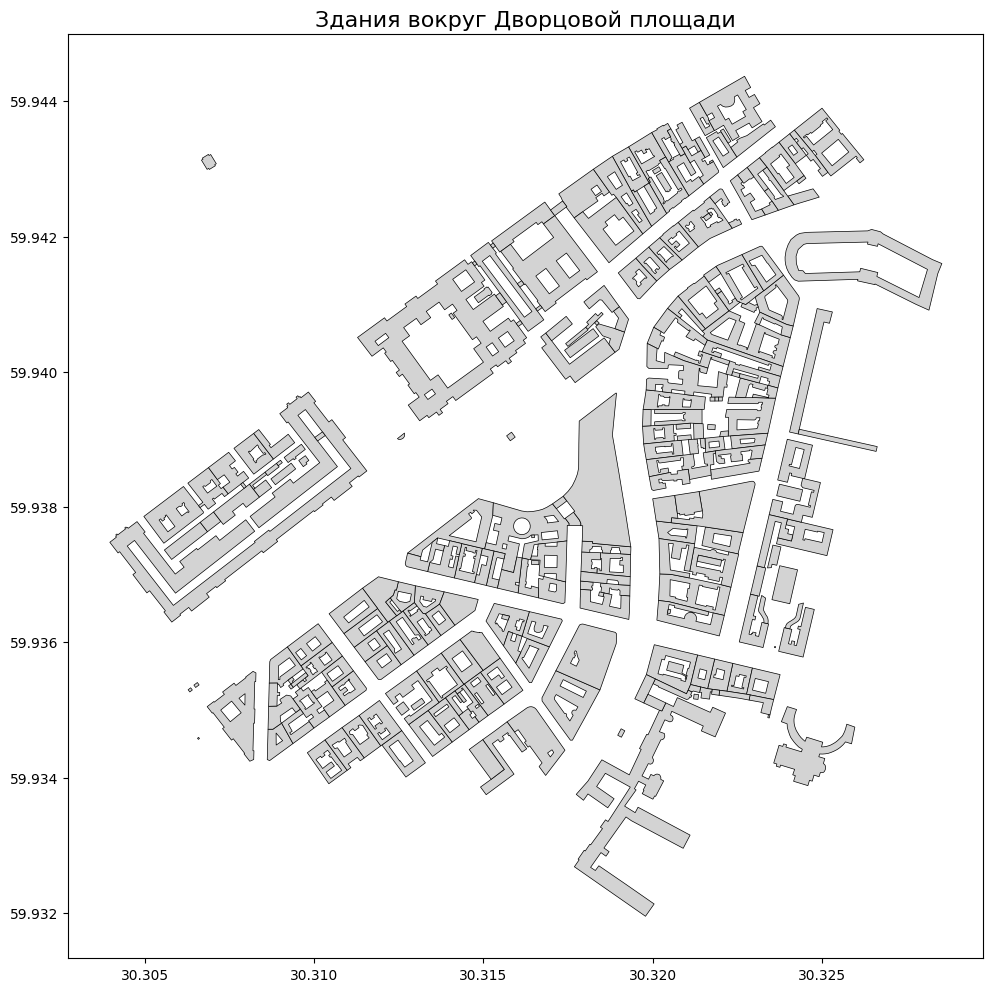

In [47]:
fig, ax = plt.subplots(figsize=(12, 12))
gdf_buildings.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)
ax.set_title("Здания вокруг Дворцовой площади", fontsize=16)
plt.show()


### Получение и визуализации сервисов

In [2]:
# Шаг 1. Определяем теги для поиска сервисов
tags = {
    'amenity': ['cafe', 'restaurant', 'shop', 'bank', 'pharmacy', 'hospital'],
    'shop': ['supermarket', 'clothes', 'electronics']
}

In [3]:
# Шаг 2. Загружаем сервисы вокруг Дворцовой площади
gdf_services = ox.features_from_address(
    'Дворцовая площадь, Санкт‑Петербург, Россия',
    tags=tags,
    dist=1000 
)

print(f"Найдено сервисов: {len(gdf_services)}")
print(f"Доступные колонки: {list(gdf_services.columns)}")

Найдено сервисов: 491
Доступные колонки: ['geometry', 'amenity', 'atm', 'branch', 'brand', 'brand:en', 'brand:ru', 'brand:wikidata', 'brand:wikipedia', 'check_date', 'contact:vk', 'name', 'opening_hours', 'operator', 'website', 'description', 'contact:email', 'contact:phone', 'contact:website', 'indoor_seating', 'int_name', 'outdoor_seating', 'wheelchair', 'cuisine', 'name:de', 'phone', 'level', 'air_conditioning', 'alt_name', 'alt_name:ru', 'delivery', 'diet:vegetarian', 'internet_access', 'internet_access:fee', 'name:en', 'name:ru', 'payment:cash', 'payment:contactless', 'payment:credit_cards', 'payment:debit_cards', 'payment:mastercard', 'payment:visa', 'reservation', 'smoking', 'takeaway', 'contact:facebook', 'contact:instagram', 'email', 'shop', 'healthcare', 'name:et', 'name:it', 'source', 'old_name', 'name:ja', 'payment:maestro', 'payment:visa_electron', 'contact:telegram', 'contact:whatsapp', 'microbrewery', 'contact:ok', 'contact:youtube', 'payment:cards', 'wifi', 'check_date:

In [ ]:
# Шаг 3. Создаём фигуру и оси и настраиваем фон карты
fig, ax = plt.subplots(figsize=(14, 14))
ax.set_facecolor('lightblue')

In [ ]:
# Шаг 5. Рисуем здания района как подложку (для контекста)
gdf_buildings = ox.geometries_from_address(
    'Дворцовая площадь, Санкт‑Петербург, Россия',
    {'building': True},
    dist=1200
)
gdf_buildings.plot(ax=ax, color='lightgray', alpha=0.6, edgecolor='darkgray')

In [ ]:
# Шаг 6. Группируем сервисы по типам и рисуем разными цветами
service_types = {
    'cafe': 'orange',
    'restaurant': 'red',
    'shop': 'green',
    'bank': 'blue',
    'pharmacy': 'purple',
    'hospital': 'pink',
    'supermarket': 'darkgreen',
    'clothes': 'brown',
    'electronics': 'black'
}

for service_type, color in service_types.items():
    subset = gdf_services[gdf_services['amenity'] == service_type]
    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=color,
            markersize=60,
            label=service_type,
            alpha=0.8
        )

In [ ]:
# Шаг 7. настраиваем и показываем график
ax.set_title("Сервисы вокруг Дворцовой площади", fontsize=18, fontweight='bold')
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
plt.axis('equal')
plt.show()

Подробнее обо всех возможностях модуля OSMnx смотрите в [документации](https://osmnx.readthedocs.io/en/stable/index.html).